In [20]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier, XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, mean_absolute_error
from sklearn.preprocessing import LabelEncoder
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('../data/training_data.csv')
print(df.shape)
print(df.columns.to_list())
print(df.head(5))

(1241, 23)
['date', 'home_team', 'away_team', 'home_goals_scored_avg', 'home_goals_conceded_avg', 'home_win_rate', 'home_draw_rate', 'home_form_points', 'home_games_played', 'home_rank', 'away_goals_scored_avg', 'away_goals_conceded_avg', 'away_win_rate', 'away_draw_rate', 'away_form_points', 'away_games_played', 'away_rank', 'rank_diff', 'goal_avg_diff', 'form_diff', 'home_goals', 'away_goals', 'outcome']
         date      home_team    away_team  home_goals_scored_avg  \
0  2014-01-07          Qatar       Jordan                    1.2   
1  2014-01-29         Mexico  South Korea                    1.2   
2  2014-02-01  United States  South Korea                    1.2   
3  2014-03-05    Switzerland      Croatia                    1.2   
4  2014-03-05          Japan  New Zealand                    1.2   

   home_goals_conceded_avg  home_win_rate  home_draw_rate  home_form_points  \
0                      1.2           0.33            0.33               1.0   
1                      

In [4]:
FEATURES = [
    'home_goals_scored_avg',
    'home_goals_conceded_avg',
    'home_win_rate',
    'home_draw_rate',
    'home_form_points',
    'home_rank',
    'away_goals_scored_avg',
    'away_goals_conceded_avg',
    'away_win_rate',
    'away_draw_rate',
    'away_form_points',
    'away_rank',
    'rank_diff',
    'goal_avg_diff',
    'form_diff'
]

X = df[FEATURES]
y_outcome = df['outcome']
y_home_goals = df['home_goals']
y_away_goals = df['away_goals']

print(X.shape)
print(y_outcome.value_counts())

(1241, 15)
outcome
2    563
0    371
1    307
Name: count, dtype: int64


In [5]:
split_idx = int(len(df) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]

y_outcome_train = y_outcome.iloc[:split_idx]
y_outcome_test = y_outcome.iloc[split_idx:]

y_home_goals_train = y_home_goals.iloc[:split_idx]
y_home_goals_test = y_home_goals.iloc[split_idx:]

y_away_goals_train = y_away_goals.iloc[:split_idx]
y_away_goals_test = y_away_goals.iloc[split_idx:]

print("Training samples: ", len(X_train))
print("Testing samples: ", len(X_test))

Training samples:  992
Testing samples:  249


In [6]:
#this model predicts the outcome, who wins
outcome_model = XGBClassifier(
    n_estimators = 300,
    max_depth = 4,
    learning_rate = 0.05,
    subsample = 0.8,
    colsample_bytree = 0.8,
    random_state = 42,
    eval_metric = 'mlogloss',
    verbosity = 0
)

outcome_model.fit(
    X_train, y_outcome_train,
    eval_set = [(X_test, y_outcome_test)],
    verbose = False
)


,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method

In [7]:
y_pred = outcome_model.predict(X_test)
accuracy = accuracy_score(y_outcome_test, y_pred)
print("Model accuracy: ", accuracy)
print(classification_report(
    y_outcome_test, y_pred, target_names=['Away Win', 'Draw', 'Home Win']
))


Model accuracy:  0.44176706827309237
              precision    recall  f1-score   support

    Away Win       0.46      0.42      0.44        78
        Draw       0.37      0.14      0.21        76
    Home Win       0.45      0.69      0.55        95

    accuracy                           0.44       249
   macro avg       0.42      0.42      0.40       249
weighted avg       0.43      0.44      0.41       249



In [8]:
#these two are goals models training
home_goals_model = XGBRegressor(
    n_estimators = 300,
    max_depth = 3,
    learning_rate = 0.05,
    subsample = 0.8,
    colsample_bytree = 0.8,
    random_state = 42,
    verbosity = 0
)

home_goals_model.fit(X_train, y_home_goals_train, verbose=False)

away_goals_model = XGBRegressor(
    n_estimators = 300,
    max_depth = 3,
    learning_rate = 0.05,
    subsample = 0.8,
    colsample_bytree = 0.8,
    random_state = 42,
    verbosity = 0
)

away_goals_model.fit(X_train, y_away_goals_train, verbose=False)


,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

In [9]:
home_pred = home_goals_model.predict(X_test)
away_pred = away_goals_model.predict(X_test)

print(f"Home goals: {mean_absolute_error(y_home_goals_test, home_pred):.2f}")
print(f"Away goals: {mean_absolute_error(y_away_goals_test, away_pred):.2f}")


Home goals: 1.04
Away goals: 0.93


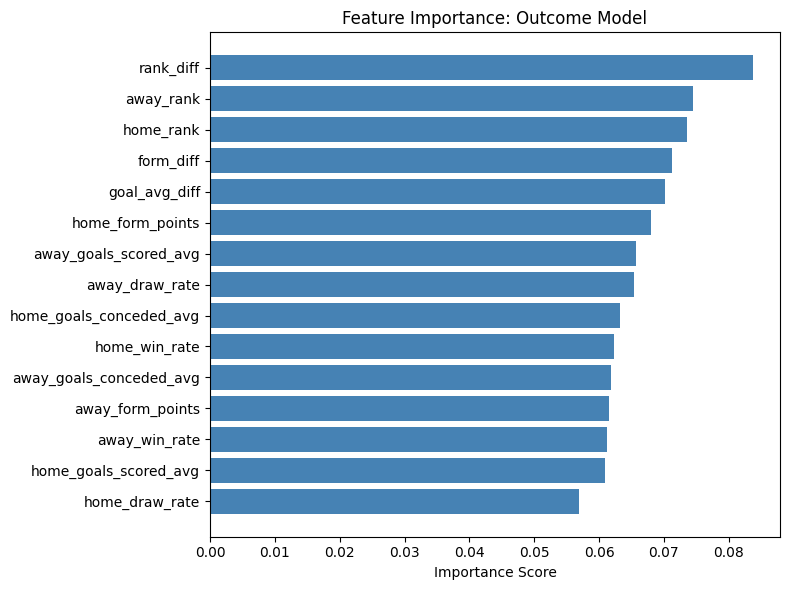


Top 5 most important features:
          feature  importance
13  goal_avg_diff    0.070163
14      form_diff    0.071307
5       home_rank    0.073545
11      away_rank    0.074480
12      rank_diff    0.083716


In [10]:
import matplotlib.pyplot as plt

importances = pd.DataFrame({
    'feature': FEATURES,
    'importance': outcome_model.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(importances['feature'], importances['importance'], color='steelblue')
plt.title('Feature Importance: Outcome Model')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../outputs/feature_importance.png')
plt.show()

print("\nTop 5 most important features:")
print(importances.tail(5)[['feature', 'importance']].to_string())

In [14]:
team_stats = pd.read_csv('../data/team_stats.csv')
home = team_stats[team_stats['team'] == 'Brazil'].iloc[0]
away = team_stats[team_stats['team'] == 'Argentina'].iloc[0]
print(team_stats.columns)

Index(['team', 'total_games', 'avg_goal_scored', 'avg_goal_conceded',
       'win_rate', 'draw_rate', 'home_goals_scored', 'home_goals_conceded',
       'home_win_rate', 'away_goals_scored', 'away_goals_conceded',
       'away_win_rate', 'fifa_rank', 'fifa_points'],
      dtype='str')


In [18]:

def predict_match_ml(home_team, away_team, team_stats,outcome_model, home_goals_model, away_goals_model):
    """
    Predict a match using trained ML models.
    """
    home = team_stats[team_stats['team'] == home_team].iloc[0]
    away = team_stats[team_stats['team'] == away_team].iloc[0]


    features = pd.DataFrame([{
        'home_goals_scored_avg': home['avg_goal_scored'],
        'home_goals_conceded_avg': home['avg_goal_conceded'],
        'home_win_rate': home['win_rate'],
        'home_draw_rate': home['draw_rate'],
        'home_form_points':        home.get('form_points', 1.0),
        'home_rank': home['fifa_rank'],
        'away_goals_scored_avg': away['avg_goal_scored'],
        'away_goals_conceded_avg': away['avg_goal_conceded'],
        'away_win_rate': away['win_rate'],
        'away_draw_rate': away['draw_rate'],
        'away_form_points': away.get('form_points', 1.0),
        'away_rank': away['fifa_rank'],
        'rank_diff': away['fifa_rank'] - home['fifa_rank'],
        'goal_avg_diff': home['avg_goal_scored'] - away['avg_goal_scored'],
        'form_diff': home.get('form_points', 1.0) - away.get('form_points', 1.0),
    }])

    outcome_probs = outcome_model.predict_proba(features)[0]
    away_win_prob = round(outcome_probs[0] * 100, 1)
    draw_prob = round(outcome_probs[1] * 100, 1)
    home_win_prob = round(outcome_probs[2] * 100, 1)

    home_goals = max(0, round(home_goals_model.predict(features)[0]))
    away_goals = max(0, round(away_goals_model.predict(features)[0]))

    if home_win_prob > away_win_prob and home_win_prob > draw_prob:
        winner ='home'
    elif away_win_prob > home_win_prob and away_win_prob > draw_prob:
        winner ='away'
    else:
        winner = 'draw'

    return{
        'home_team': home_team,
        'away_team': away_team,
        'predicted_home_goals': int(home_goals),
        'predicted_away_goals': int(away_goals),
        'home_win_prob': home_win_prob,
        'draw_prob' : draw_prob,
        'away_win_prob': away_win_prob,
        'predicted_winner': winner
    }

result = predict_match_ml(
    'Brazil', 'Argentina', team_stats, outcome_model, home_goals_model, away_goals_model
)

print("Brazil vs Argentina")
for k, v in result.items():
    print(f" {k} : {v}")

Brazil vs Argentina
 home_team : Brazil
 away_team : Argentina
 predicted_home_goals : 2
 predicted_away_goals : 2
 home_win_prob : 29.399999618530273
 draw_prob : 48.29999923706055
 away_win_prob : 22.299999237060547
 predicted_winner : draw


In [21]:
os.makedirs('../src', exist_ok=True)

joblib.dump(outcome_model, '../src/outcome_model.pkl')
joblib.dump(home_goals_model, '../src/home_goals_model.pkl')
joblib.dump(away_goals_model, '../src/away_goals_model.pkl')

print("all models saved.")

all models saved.
